In [29]:
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
import pandas as pd
from PIL import Image
from pathlib import Path
import shutil

**Root**

In [2]:
root_path = r"D:\Project\CPV_paper\datasets\raw\DomainNet\DG_Benchmark"
root = os.listdir(root_path)

**Dataset overview**

In [3]:
rows = []

for domain in os.listdir(root_path):
    domain_path = os.path.join(root_path, domain)

    if not os.path.isdir(domain_path):
        continue

    for category in os.listdir(domain_path):
        category_path = os.path.join(domain_path, category)

        if not os.path.isdir(category_path):
            continue

        for image in os.listdir(category_path):
            image_path = os.path.join(category_path, image)

            if not os.path.isfile(image_path):
                continue

            rows.append({
                "image_path": image_path,
                "image_name": image,
                "domain": domain,
                "category": category
            })

df = pd.DataFrame(rows)

df.head()

,image_path,image_name,domain,category
0,D:\Project\CPV_paper\datasets\raw\DomainNet\DG...,clipart_001_000001.jpg,clipart,aircraft_carrier
1,D:\Project\CPV_paper\datasets\raw\DomainNet\DG...,clipart_001_000002.jpg,clipart,aircraft_carrier
2,D:\Project\CPV_paper\datasets\raw\DomainNet\DG...,clipart_001_000003.jpg,clipart,aircraft_carrier
3,D:\Project\CPV_paper\datasets\raw\DomainNet\DG...,clipart_001_000004.jpg,clipart,aircraft_carrier
4,D:\Project\CPV_paper\datasets\raw\DomainNet\DG...,clipart_001_000005.jpg,clipart,aircraft_carrier


In [4]:
print(f"""
Number of domains: {len(df['domain'].unique())}
{df['domain'].unique()}

Number of categories: {len(df['category'].unique())}
{df['category'].unique()}

Number of images: {len(df)}
""")


Number of domains: 6
['clipart' 'infograph' 'painting' 'quickdraw' 'real' 'sketch']

Number of categories: 345
['aircraft_carrier' 'airplane' 'alarm_clock' 'ambulance' 'angel'
 'animal_migration' 'ant' 'anvil' 'apple' 'arm' 'asparagus' 'axe'
 'backpack' 'banana' 'bandage' 'barn' 'baseball' 'baseball_bat' 'basket'
 'basketball' 'bat' 'bathtub' 'beach' 'bear' 'beard' 'bed' 'bee' 'belt'
 'bench' 'bicycle' 'binoculars' 'bird' 'birthday_cake' 'blackberry'
 'blueberry' 'book' 'boomerang' 'bottlecap' 'bowtie' 'bracelet' 'brain'
 'bread' 'bridge' 'broccoli' 'broom' 'bucket' 'bulldozer' 'bus' 'bush'
 'butterfly' 'cactus' 'cake' 'calculator' 'calendar' 'camel' 'camera'
 'camouflage' 'campfire' 'candle' 'cannon' 'canoe' 'car' 'carrot' 'castle'
 'cat' 'ceiling_fan' 'cello' 'cell_phone' 'chair' 'chandelier' 'church'
 'circle' 'clarinet' 'clock' 'cloud' 'coffee_cup' 'compass' 'computer'
 'cookie' 'cooler' 'couch' 'cow' 'crab' 'crayon' 'crocodile' 'crown'
 'cruise_ship' 'cup' 'diamond' 'dishwasher' 

**Domain distribution**

In [5]:
def bar_plot(x, y, x_label, y_label, title, data):
    plt.figure(figsize=(20, 5))
    sns.barplot(x=x, y=y, data=data, hue=x, palette='viridis')
    plt.xlabel(x_label)    
    plt.ylabel(y_label)
    plt.title(title)
    plt.tight_layout()
    plt.plot()


Image per domain:
      domain   count
0       real  175327
1  quickdraw  172500
2   painting   75759
3     sketch   70386
4  infograph   53201
5    clipart   48833

Largest domain:
domain    3
count     0
dtype: int64

Smallest domain:
domain    5
count     5
dtype: int64

Imbalance ratio:
3.59



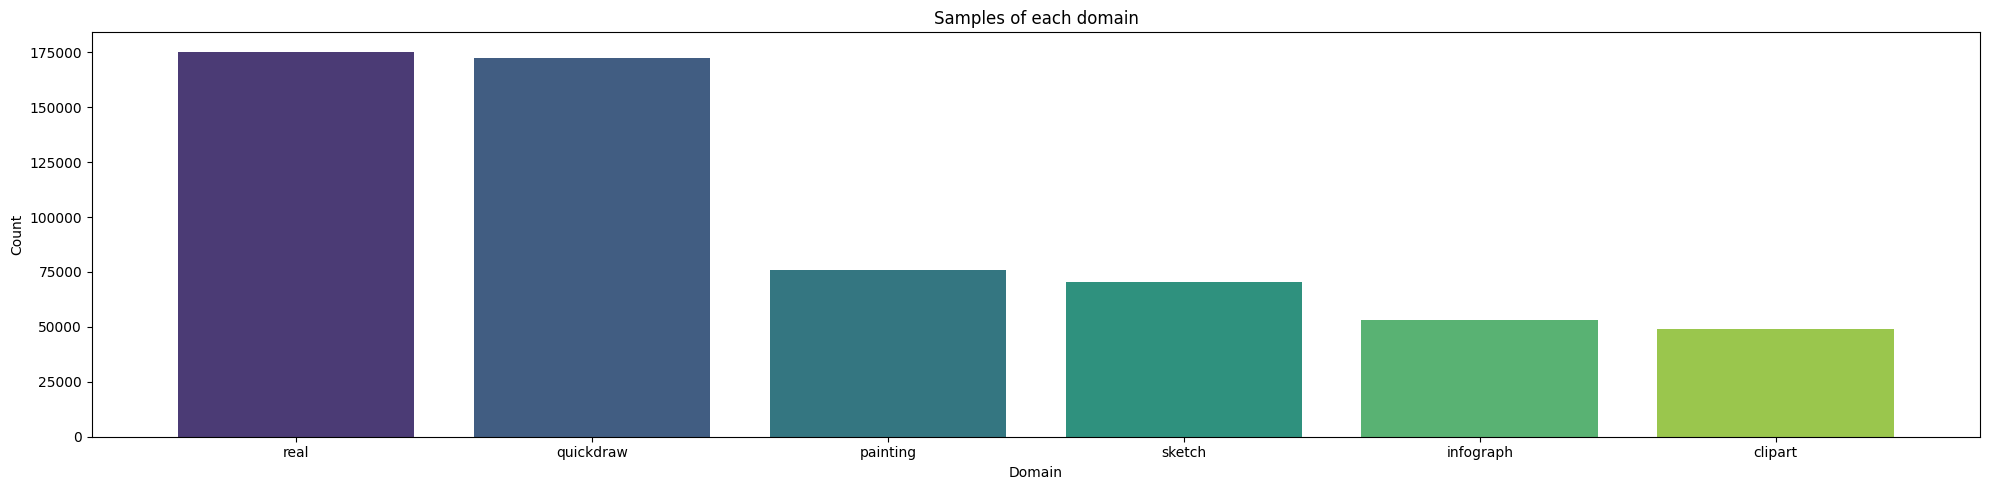

In [6]:
domain_counts = df['domain'].value_counts().reset_index()

print(f"""
Image per domain:
{domain_counts}

Largest domain:
{domain_counts.idxmax()}

Smallest domain:
{domain_counts.idxmin()}

Imbalance ratio:
{domain_counts['count'].max() / domain_counts['count'].min():.2f}
""")

bar_plot('domain', 'count', 'Domain', 'Count', 'Samples of each domain', domain_counts)

**Class distribution**


Top frequent classes:
      category  count
0         tree   2799
1    golf_club   2773
2     squirrel   2762
3          dog   2609
4        whale   2575
5  spreadsheet   2546
6      snowman   2524
7        tiger   2515
8        table   2500
9         shoe   2410

Rare classes:
        category  count
335    stop_sign   1087
336       cannon   1064
337   calculator   1038
338      matches   1024
339          saw    988
340   camouflage    973
341      rainbow    966
342      dresser    952
343     calendar    899
344  ceiling_fan    878

Imbalance ratio:
3.19



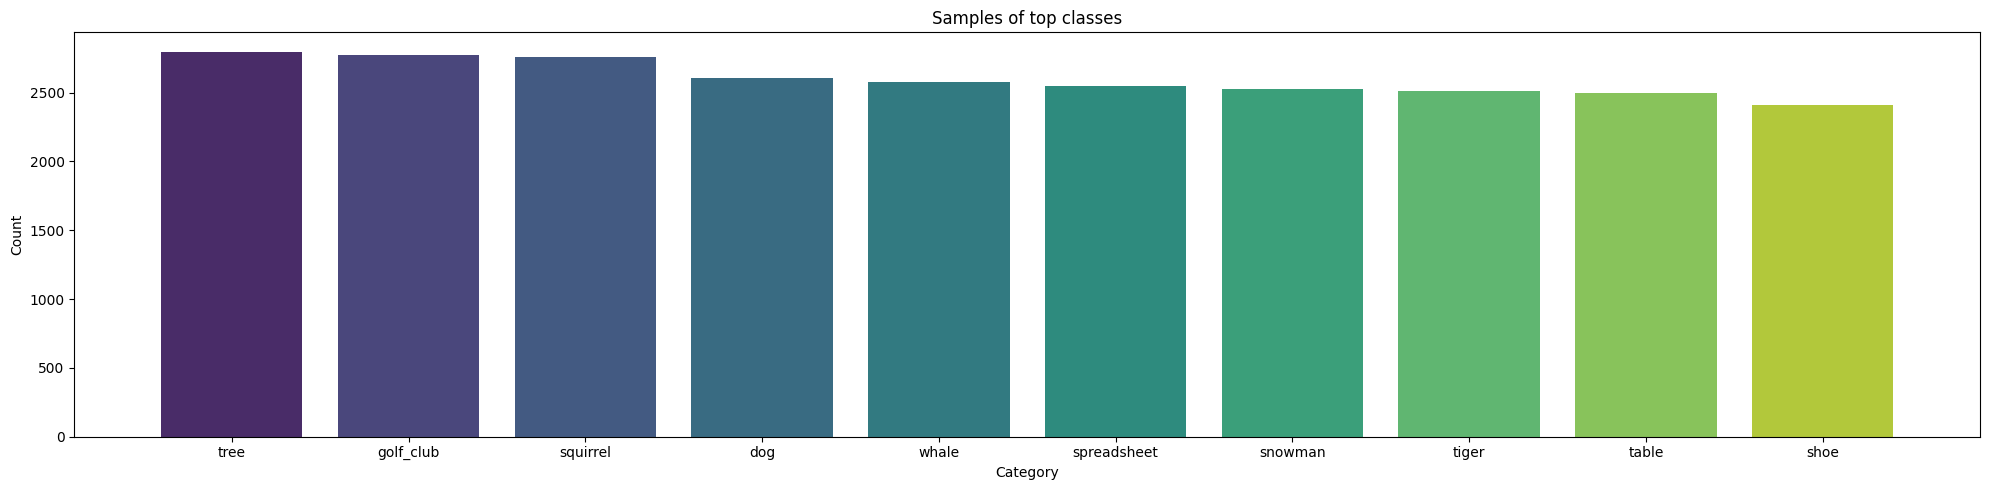

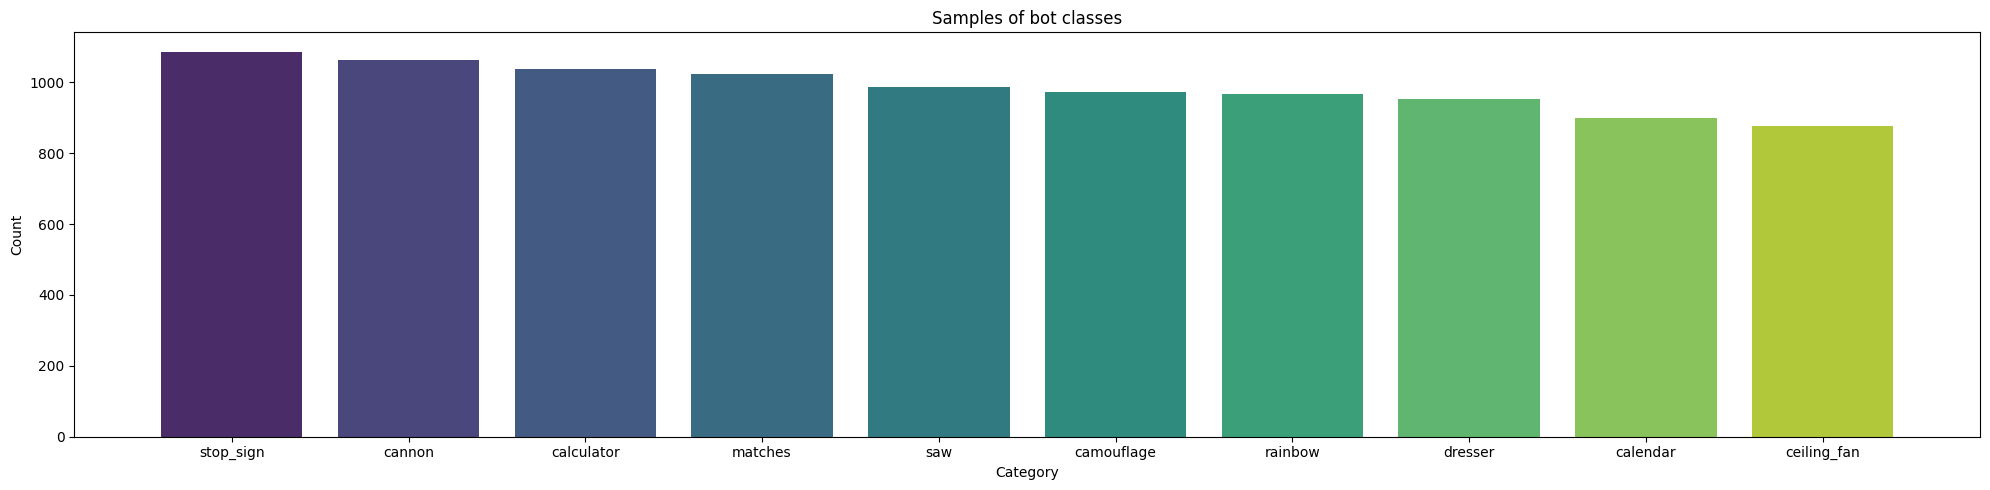

In [7]:
class_counts = df['category'].value_counts().reset_index()

print(f"""
Top frequent classes:
{class_counts.head(10)}

Rare classes:
{class_counts.tail(10)}

Imbalance ratio:
{class_counts['count'].max() / class_counts['count'].min():.2f}
""")

bar_plot('category', 'count', 'Category', 'Count', 'Samples of top classes', class_counts.head(10))
bar_plot('category', 'count', 'Category', 'Count', 'Samples of bot classes', class_counts.tail(10))

**Visual domain shift**

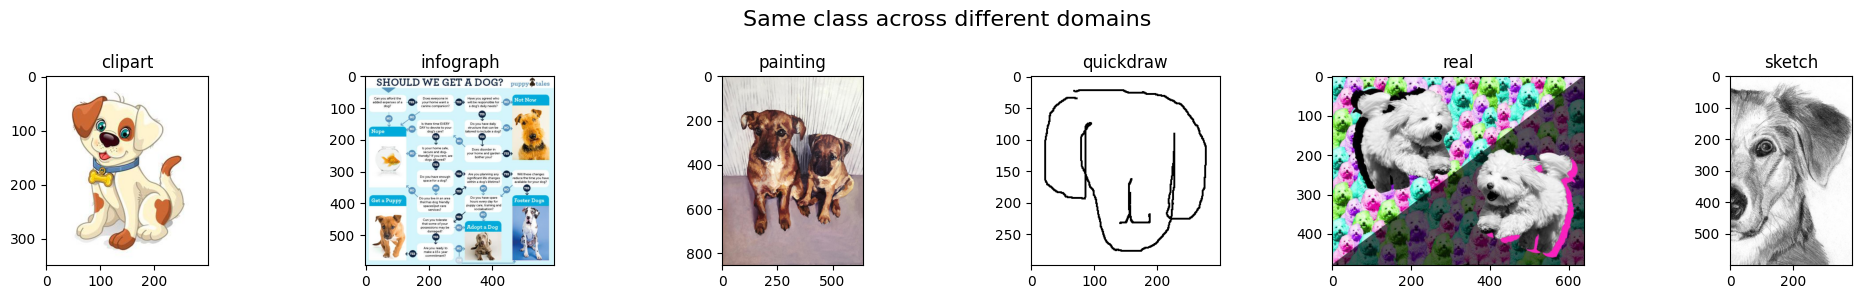

In [8]:
idx = 67
fig, ax = plt.subplots(1, 6, figsize=(20, 3))

ax[0].imshow(Image.open(df[(df['category'] == 'dog') & (df['domain'] == 'clipart')]['image_path'].iloc[idx]))
ax[0].set_title('clipart')

ax[1].imshow(Image.open(df[(df['category'] == 'dog') & (df['domain'] == 'infograph')]['image_path'].iloc[idx]))
ax[1].set_title('infograph')

ax[2].imshow(Image.open(df[(df['category'] == 'dog') & (df['domain'] == 'painting')]['image_path'].iloc[idx]))
ax[2].set_title('painting')

ax[3].imshow(Image.open(df[(df['category'] == 'dog') & (df['domain'] == 'quickdraw')]['image_path'].iloc[idx]))
ax[3].set_title('quickdraw')

ax[4].imshow(Image.open(df[(df['category'] == 'dog') & (df['domain'] == 'real')]['image_path'].iloc[idx]))
ax[4].set_title('real')

ax[5].imshow(Image.open(df[(df['category'] == 'dog') & (df['domain'] == 'sketch')]['image_path'].iloc[idx]))
ax[5].set_title('sketch')

plt.suptitle("Same class across different domains", fontsize=16)
plt.tight_layout()
plt.show()

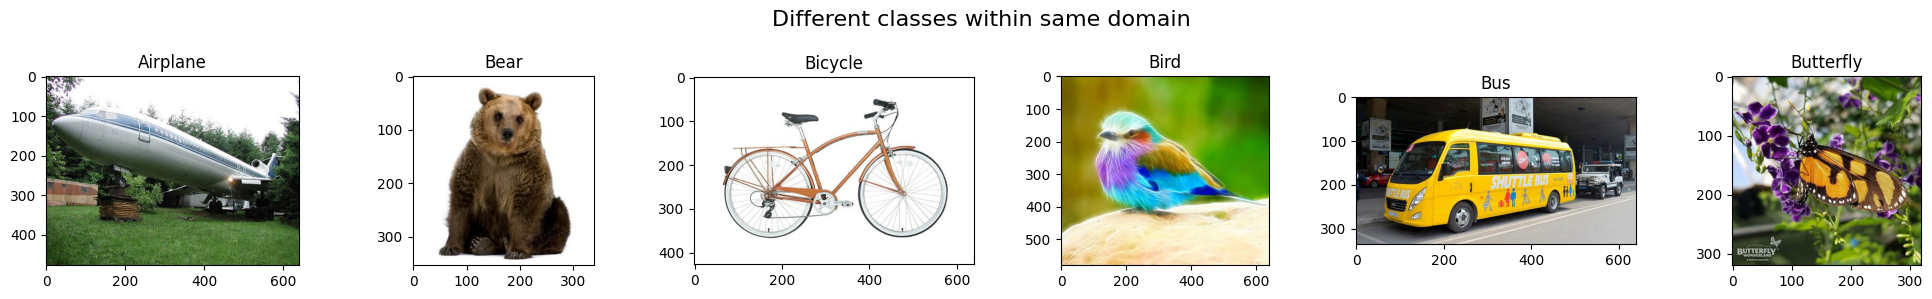

In [9]:
idx = 36
fig, ax = plt.subplots(1, 6, figsize=(20, 3))

ax[0].imshow(Image.open(df[(df['category'] == 'airplane') & (df['domain'] == 'real')]['image_path'].iloc[idx]))
ax[0].set_title('Airplane')

ax[1].imshow(Image.open(df[(df['category'] == 'bear') & (df['domain'] == 'real')]['image_path'].iloc[idx]))
ax[1].set_title('Bear')

ax[2].imshow(Image.open(df[(df['category'] == 'bicycle') & (df['domain'] == 'real')]['image_path'].iloc[idx]))
ax[2].set_title('Bicycle')

ax[3].imshow(Image.open(df[(df['category'] == 'bird') & (df['domain'] == 'real')]['image_path'].iloc[idx]))
ax[3].set_title('Bird')

ax[4].imshow(Image.open(df[(df['category'] == 'bus') & (df['domain'] == 'real')]['image_path'].iloc[idx]))
ax[4].set_title('Bus')

ax[5].imshow(Image.open(df[(df['category'] == 'butterfly') & (df['domain'] == 'real')]['image_path'].iloc[idx]))
ax[5].set_title('Butterfly')

plt.suptitle("Different classes within same domain", fontsize=16)
plt.tight_layout()
plt.show()

**Image quality**

In [10]:
widths, heights, aspect_ratios, corrupt = [], [], [], []

for path in df['image_path']:
    try:
        with Image.open(path) as img:
            img.verify()

        with Image.open(path) as img:
            w, h = img.size

        widths.append(w)
        heights.append(h)
        aspect_ratios.append(w/h)
        corrupt.append(False)

    except Exception:
        widths.append(None)
        heights.append(None)
        aspect_ratios.append(None)
        corrupt.append(True)

df = df.copy()
df["width"] = widths
df["height"] = heights
df["aspect_ratio"] = aspect_ratios
df["corrupt"] = corrupt

In [11]:
df.head()

,image_path,image_name,domain,category,width,height,aspect_ratio,corrupt
0,D:\Project\CPV_paper\datasets\raw\DomainNet\DG...,clipart_001_000001.jpg,clipart,aircraft_carrier,573,612,0.936275,False
1,D:\Project\CPV_paper\datasets\raw\DomainNet\DG...,clipart_001_000002.jpg,clipart,aircraft_carrier,640,559,1.144902,False
2,D:\Project\CPV_paper\datasets\raw\DomainNet\DG...,clipart_001_000003.jpg,clipart,aircraft_carrier,640,384,1.666667,False
3,D:\Project\CPV_paper\datasets\raw\DomainNet\DG...,clipart_001_000004.jpg,clipart,aircraft_carrier,450,450,1.000000,False
4,D:\Project\CPV_paper\datasets\raw\DomainNet\DG...,clipart_001_000005.jpg,clipart,aircraft_carrier,300,389,0.771208,False


In [12]:
print(f"""
Image sizes stats:
{df[["width", "height", "aspect_ratio"]].describe()}

Corrupt images:
{df[df["corrupt"] == True][["image_path", "domain", "category"]]}

Small images:
{df[(df["width"] < 32) | (df["height"] < 32)][["image_path", "domain", "category", "width", "height"]]}

Strange aspect ratios images:
{df[(df["aspect_ratio"] < 0.3) | (df["aspect_ratio"] > 3.0)][["image_path", "domain", "category", "width", "height", "aspect_ratio"]].value_counts().sum()}
""")


Image sizes stats:
               width         height   aspect_ratio
count  596006.000000  596006.000000  596006.000000
mean      473.646032     469.452110       1.148457
std       159.618226     386.589537       0.416341
min        50.000000      24.000000       0.019524
25%       300.000000     300.000000       1.000000
50%       500.000000     360.000000       1.000000
75%       640.000000     512.000000       1.333333
max       640.000000   30219.000000      26.666667

Corrupt images:
Empty DataFrame
Columns: [image_path, domain, category]
Index: []

Small images:
                                               image_path  domain    category  \
572631  D:\Project\CPV_paper\datasets\raw\DomainNet\DG...  sketch  skateboard   

        width  height  
572631    640      24  

Strange aspect ratios images:
9172



**Split quality**

In [14]:
split_path = r"D:\Project\CPV_paper\datasets\raw\DomainNet\txtlist"
split = os.listdir(split_path)

In [15]:
rows = []

for txt in split:
    txt_path = os.path.join(split_path, txt)
    domain = txt.split('_')[0]
    split2 = "train" if "train" in txt else "test"

    with open(txt_path, 'r') as f:
        contents = f.readlines()
        
        for content in contents:
            rows.append({
                "image_path": content.split()[0],
                "domain": domain,
                "split": split2,
                "label": content.split()[-1]
            })

In [16]:
df = pd.DataFrame(rows)

df.head()

,image_path,domain,split,label
0,clipart/aircraft_carrier/clipart_001_000005.jpg,clipart,test,0
1,clipart/aircraft_carrier/clipart_001_000008.jpg,clipart,test,0
2,clipart/aircraft_carrier/clipart_001_000010.jpg,clipart,test,0
3,clipart/aircraft_carrier/clipart_001_000013.jpg,clipart,test,0
4,clipart/aircraft_carrier/clipart_001_000014.jpg,clipart,test,0


In [17]:
print(f"""
Train size:
{len(df[df['split'] == 'train'])}

Test size:
{len(df[df['split'] == 'test'])}

Class balance per split:
{pd.crosstab(df["label"], df["split"]).head()}

Domain balance per split:
{pd.crosstab(df["domain"], df["split"]).head()}
""")


Train size:
409832

Test size:
176743

Class balance per split:
split  test  train
label             
0       362    839
1       419    971
10      589   1362
100     576   1340
101     418    968

Domain balance per split:
split       test   train
domain                  
clipart    14604   33525
infograph  15582   36023
painting   21850   50416
quickdraw  51750  120750
real       52041  120906



**Domain Generalization Protocol**

In [21]:
def source_target_plot(target_domains):
    target_df = df[df['domain'].isin(target_domains)]
    source_df = df[~df['domain'].isin(target_domains)]

    target_split = target_df.groupby('split')['domain'].value_counts().reset_index()
    source_split = source_df.groupby('split')['domain'].value_counts().reset_index()

    target_split["dataset"] = "target"
    source_split["dataset"] = "source"

    plot_df = pd.concat([source_split, target_split], ignore_index=True)

    plot_df["group"] = (plot_df["dataset"].str.capitalize() + " - " + plot_df["split"].str.capitalize())

    domain_order = (plot_df.groupby("domain")["count"].sum().sort_values(ascending=False).index)

    plt.figure(figsize=(20, 5))

    ax = sns.barplot(data=plot_df,x="domain",y="count",hue="group",order=domain_order)

    plt.title("Train/Test Distribution for Source and Target Domains")
    plt.xlabel("Domain")
    plt.ylabel("Number of Images")
    plt.xticks(rotation=30)
    plt.legend(title="Dataset Split")
    plt.tight_layout()
    plt.show()

    return source_df, target_df

**Case 1**

In [20]:
def copy_images(df, root_path, output_path):
    root_path = Path(root_path)
    output_path = Path(output_path)
    output_path.mkdir(parents=True, exist_ok=True)

    for image_path in df["image_path"]:
        parts = image_path.split("/")

        domain = parts[1]
        category = parts[2]

        src = root_path / image_path
        dst_dir = output_path / domain / category

        dst_dir.mkdir(parents=True, exist_ok=True)

        shutil.copy2(src, dst_dir)

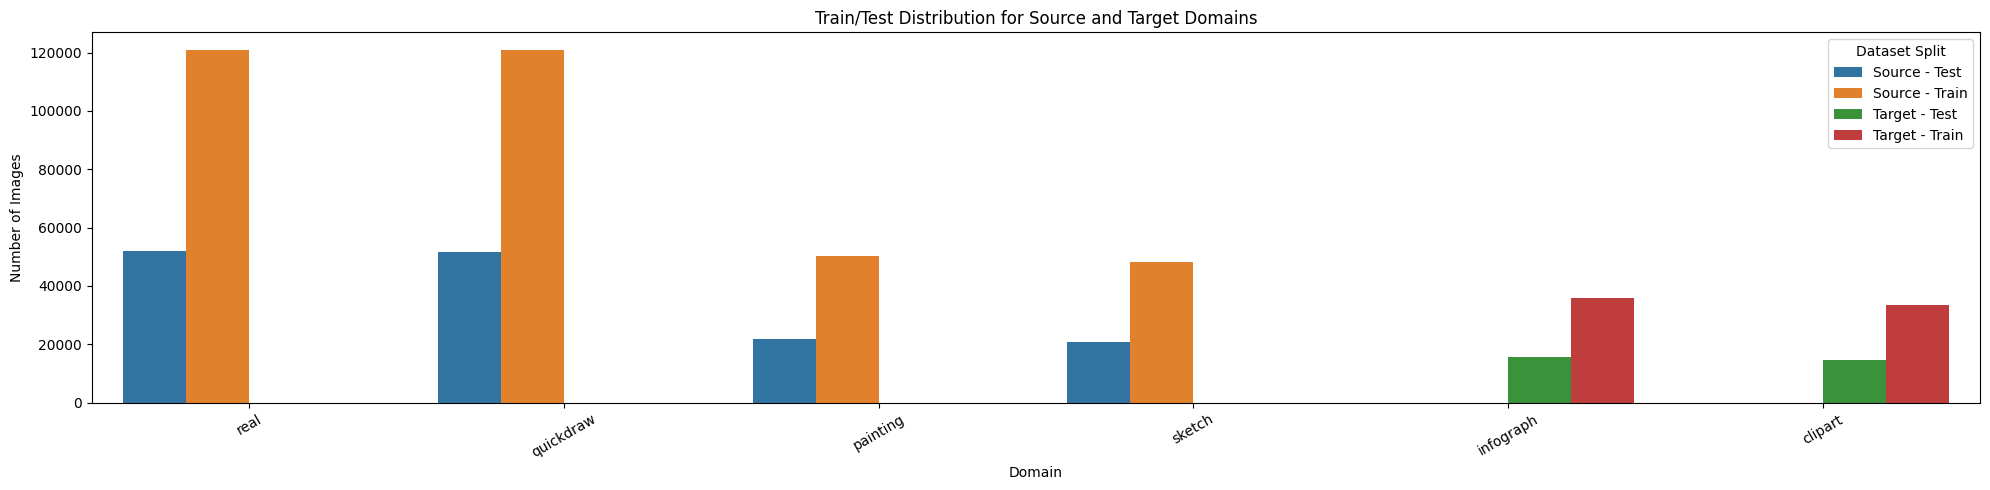

In [22]:
target_domains = ['clipart', 'infograph']
source_df, target_df = source_target_plot(target_domains)

In [30]:
target_path = Path(r"D:\Project\CPV_paper\datasets\processed\DomainNet\clipart_infograph")

target_train_df = target_df[target_df["split"] == "train"]
target_test_df = target_df[target_df["split"] == "test"]

target_train_path = target_path / "train"
target_test_path = target_path / "test"

target_train_path.mkdir(parents=True, exist_ok=True)
target_test_path.mkdir(parents=True, exist_ok=True)

copy_images(target_train_df, root_path, target_train_path)
copy_images(target_test_df, root_path, target_test_path)

**Case 2**

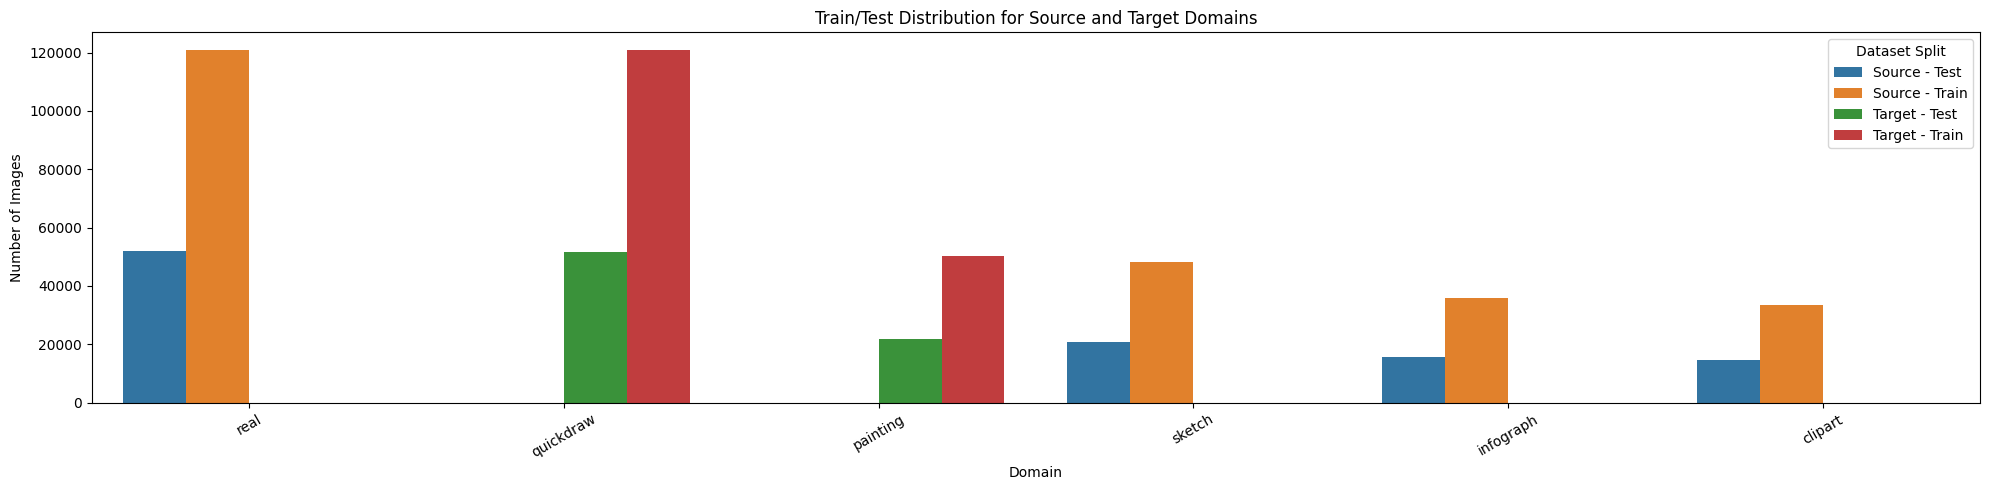

In [33]:
target_domains = ['painting', 'quickdraw']
source_df, target_df = source_target_plot(target_domains)

In [34]:
target_path = Path(r"D:\Project\CPV_paper\datasets\processed\DomainNet\painting_quickdraw")

target_train_df = target_df[target_df["split"] == "train"]
target_test_df = target_df[target_df["split"] == "test"]

target_train_path = target_path / "train"
target_test_path = target_path / "test"

target_train_path.mkdir(parents=True, exist_ok=True)
target_test_path.mkdir(parents=True, exist_ok=True)

copy_images(target_train_df, root_path, target_train_path)
copy_images(target_test_df, root_path, target_test_path)

**Case 3**

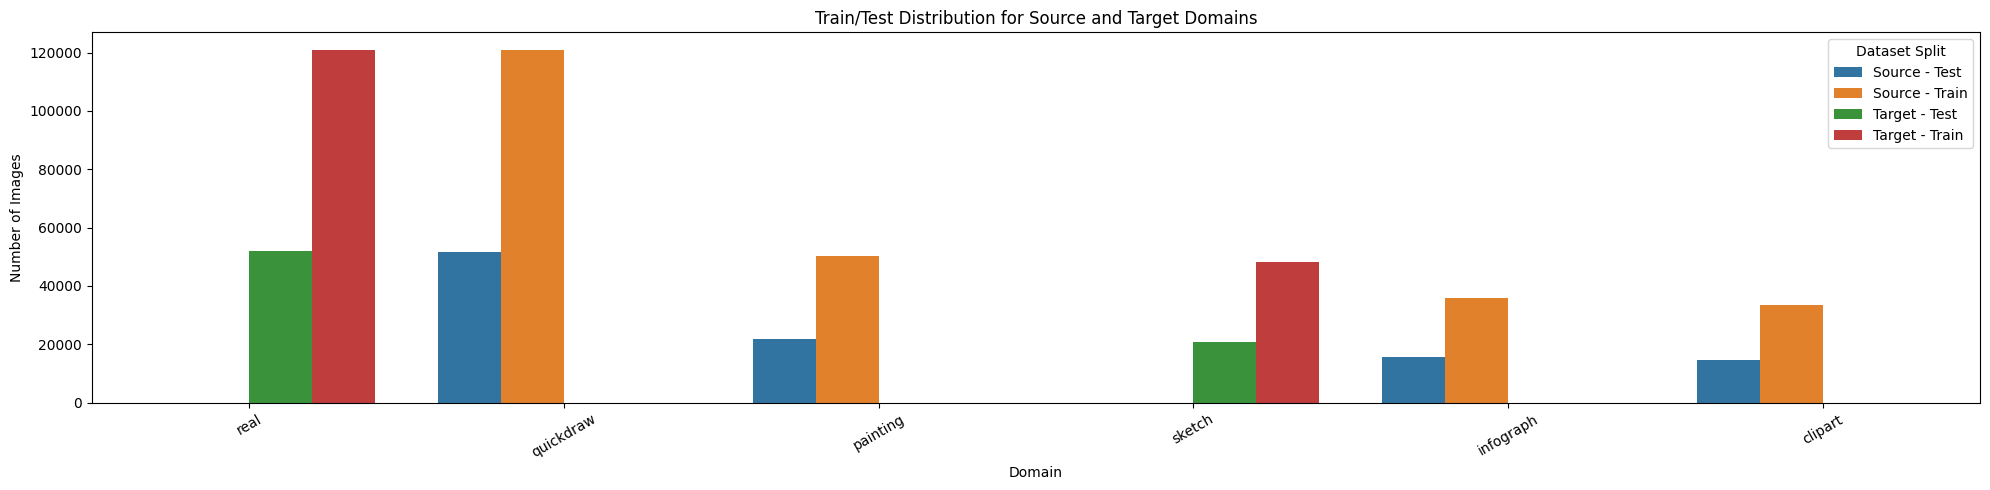

In [35]:
target_domains = ['real', 'sketch']
source_df, target_df = source_target_plot(target_domains)

In [36]:
target_path = Path(r"D:\Project\CPV_paper\datasets\processed\DomainNet\real_sketch")

target_train_df = target_df[target_df["split"] == "train"]
target_test_df = target_df[target_df["split"] == "test"]

target_train_path = target_path / "train"
target_test_path = target_path / "test"

target_train_path.mkdir(parents=True, exist_ok=True)
target_test_path.mkdir(parents=True, exist_ok=True)

copy_images(target_train_df, root_path, target_train_path)
copy_images(target_test_df, root_path, target_test_path)